## 1. Set up

In [1]:
!pip install -U pip
!pip install -U transformers accelerate peft datasets bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.3 MB/s eta 0:00:0000:010:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 86.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 79.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 19.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 91.2 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 28.8 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 15.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 16.8 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 14.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Train Model

In [2]:
# ==============================================================================
# 1. Library Import
# ==============================================================================
import torch
from pathlib import Path
from datasets import load_dataset
from peft import LoraConfig
from transformers import (
    AutoTokenizer,
    LlavaNextForConditionalGeneration,
    LlavaNextProcessor,
    BitsAndBytesConfig,
    TrainingArguments
)
from trl import SFTTrainer, SFTConfig

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
# ==============================================================================
# 2. LOAD & FORMAT DATASET
# ==============================================================================

MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"
OUTPUT_DIR = Path("/kaggle/working/output") / "llava-med-instruct-finetuned"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#Load dataset
DATA_FILE = "/kaggle/input/ft-train-dataset/Passed_Dataset.json"
print("Loading dataset...")
dataset = load_dataset("json", data_files=DATA_FILE, split="train")

print(f"Total number of samples in dataset: {len(dataset)}")

def format_instruction_chatml(sample):
    """
    Maps 'question' -> User role
    Combines 'answer_diagnosis' and 'diagnostic_reasoning' -> Assistant role
    """
    # Combining diagnosis and reasoning as requested
    assistant_content = f"Diagnosis: {sample['answer_diagnosis']}\n\nReasoning: {sample['diagnostic_reasoning']}"
    
    return {
        "messages": [
            {"role": "user", "content": sample['question']},
            {"role": "assistant", "content": assistant_content}
        ]
    }

print("Formatting dataset...")
dataset = dataset.map(format_instruction_chatml, remove_columns=dataset.column_names)

Loading dataset...


Generating train split: 0 examples [00:00, ? examples/s]

Total number of samples in dataset: 286
Formatting dataset...


Map:   0%|          | 0/286 [00:00<?, ? examples/s]

In [10]:
# ==============================================================================
# 3. LOAD PROCESSOR & MODEL (T4 OPTIMIZED)
# ==============================================================================
print("Loading Processor & Model...")

processor = LlavaNextProcessor.from_pretrained(MODEL_ID)
processor.tokenizer.padding_side = "right"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, # Float16 for T4
    bnb_4bit_use_double_quant=True
)

model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    device_map="auto" 
)

# ==============================================================================
# 4. CONFIGURE LoRA
# ==============================================================================
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj", 
        "gate_proj", "up_proj", "down_proj"
    ],
    modules_to_save=None,
)

# ==============================================================================
# 5. TRAINING ARGUMENTS (T4 SAFE)
# ==============================================================================
training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=3,                 # 3 Epochs for instruction tuning
    per_device_train_batch_size=4,      # Safe batch size for T4 VRAM
    gradient_accumulation_steps=4,      # Accumulate to effective batch size 16
    learning_rate=2e-4,
    logging_steps=10,
    save_strategy="epoch",
    
    # T4 CRITICAL SETTINGS:
    fp16=False,                          # Enable FP16
    bf16=True,                         # Disable BF16 (Avoid T4 crash)    
    
    optim="paged_adamw_32bit",
    report_to="none",
    gradient_checkpointing=True,        # Saves VRAM
    max_length=1536,                # 1536 is very safe for T4. 2048 might push limits.
    dataset_text_field="messages",
    packing=False
)

# ==============================================================================
# 6. START TRAINING
# ==============================================================================
print("Initializing SFT Trainer...")

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    processing_class=processor.tokenizer,
    peft_config=peft_config,
)

print("Starting Supervised Fine-Tuning...")
trainer.train()

# ==============================================================================
# 7. SAVE ADAPTERS
# ==============================================================================
print(f"Saving fine-tuned model to {OUTPUT_DIR}...")
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training Complete. Model saved.")

Loading Processor & Model...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 10.19 MiB is free. Process 10549 has 14.73 GiB memory in use. Of the allocated memory 14.63 GiB is allocated by PyTorch, and 1.93 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### Small Test after Training

In [2]:
import torch
from pathlib import Path
from transformers import (
    LlavaNextProcessor,
    LlavaNextForConditionalGeneration,
    BitsAndBytesConfig
)
from peft import PeftModel

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
BASE_MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"
ADAPTER_PATH = "/kaggle/input/output/output/llava-med-instruct-finetuned"

# ==============================================================================
# 2. LOAD MODEL & ADAPTERS
# ==============================================================================
print(f"Loading Base Model (4-bit) on {torch.cuda.get_device_name(0)}...")

# Detect if we are on A100 (use bfloat16) or T4 (use float16)
if torch.cuda.is_bf16_supported():
    compute_dtype = torch.bfloat16
    print(" Using bfloat16 (A100/H100 detected)")
else:
    compute_dtype = torch.float16
    print(" Using float16 (T4/V100 detected)")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True
)

# Load Base Model
model = LlavaNextForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=compute_dtype,
    low_cpu_mem_usage=True,
    device_map="auto"
)

print(f"Loading LoRA Adapters from {ADAPTER_PATH}...")
# Load the Fine-Tuned Adapters using the CORRECT PATH
model = PeftModel.from_pretrained(model, ADAPTER_PATH)

# Load Processor
processor = LlavaNextProcessor.from_pretrained(BASE_MODEL_ID)



In [4]:
# ==============================================================================
# Simple test (text-only)
# ==============================================================================
def ask_med_question(question):
    print(f"\n QUESTION: {question}")
    
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": question},
            ],
        },
    ]
    
    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(text=prompt, return_tensors="pt").to("cuda")

    print("MODEL Generating Answer...")
    output = model.generate(
        **inputs, 
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )
    
    answer = processor.decode(output[0], skip_special_tokens=True)
    if "[/INST]" in answer:
        answer = answer.split("[/INST]")[-1].strip()
        
    print(f"ANSWER: \n{answer}\n" + "-"*50)

# ==============================================================================
# 4. TEST IT
# ==============================================================================
ask_med_question("What are the symptoms of Lymphocytic Choriomeningitis (LCM)?")
ask_med_question("What causes Type 2 Diabetes?")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



 QUESTION: What are the symptoms of Lymphocytic Choriomeningitis (LCM)?
MODEL Generating Answer...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


ANSWER: 
Diagnosis: Lymphocytic Choriomeningitis

Reasoning: The patient presents with symptoms including fever, headache, nausea, and stiff neck, which are consistent with meningitis. The presence of lymphocytic pleocytosis in the CSF supports this diagnosis. Given the potential for LCM complications, testing for IgM antibodies to LCMV in the CSF is warranted.
--------------------------------------------------

 QUESTION: What causes Type 2 Diabetes?
MODEL Generating Answer...
ANSWER: 
Type 2 diabetes is a complex disease caused by a combination of genetic and environmental factors. The primary risk factors include obesity, physical inactivity, and a family history of diabetes. Other factors, such as age, race, and gestational diabetes, also contribute to the development of Type 2 diabetes.

In Type 2 diabetes, the body becomes resistant to insulin, a hormone produced by the pancreas that helps regulate blood sugar levels. Insulin resistance is caused by a combination of genetic and e

## 3. Demo Inference

In [5]:
from PIL import Image
import torch
from pathlib import Path
from transformers import (
    LlavaNextProcessor,
    LlavaNextForConditionalGeneration,
    BitsAndBytesConfig
)
from peft import PeftModel

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
BASE_MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"
ADAPTER_PATH = "/kaggle/input/output/output/llava-med-instruct-finetuned"
# ==============================================================================
# 2. LOAD MODEL & PROCESSOR (T4 SAFE)
# ==============================================================================
print(f"🚀 Loading model on {torch.cuda.get_device_name(0)}")

compute_dtype = torch.float16  # FORCE fp16 for T4

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True
)

model = LlavaNextForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=compute_dtype,
    device_map="balanced_low_0",
    max_memory={0: "13GiB", "cpu": "30GiB"},
    low_cpu_mem_usage=True
)

model = PeftModel.from_pretrained(
    model,
    ADAPTER_PATH,
    torch_dtype=compute_dtype
)

model.eval()

processor = LlavaNextProcessor.from_pretrained(BASE_MODEL_ID)


🚀 Loading model on Tesla T4


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

In [7]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# ==============================================================================
# 1. SYSTEM PROMPT
# ==============================================================================
SYSTEM_PROMPT = (
    "You are a medical expert. Given the clinical case and image, "
    "provide a concise diagnosis and a clinical rationale.\n\n"
    "Format your answer exactly as:\n"
    "Answer: <diagnosis>\n"
    "Clinical Rationale: <reasoning>"
)

# ==============================================================================
# 2. TEST CASE
# ==============================================================================
test_case = {
    "question": (
        "A 7-year-old girl, hailing from a rural village in the Kwango Province of the "
        "Democratic Republic of Congo, presents with a history of an itchy, weeping skin "
        "lesion on her left forearm that appeared approximately one month ago. She reports "
        "intermittent fevers, headaches, and joint aches for the past two weeks. Her mother "
        "notes that the lesion started as a small bump and has since enlarged into a raised, "
        "cauliflower-like sore that bleeds easily when touched. The girl spends most of her "
        "time playing outdoors and has several small cuts and abrasions on her extremities "
        "from previous falls. She has not received any vaccinations for tropical diseases. "
        "On physical examination, her temperature is 38.2°C. A single, large, fungating, "
        "raspberry-like papule, approximately 2 cm in diameter, is present on her left "
        "forearm, exuding a yellowish, sero-purulent fluid. There is mild tenderness and "
        "palpable enlargement of the left epitrochlear and axillary lymph nodes. "
        "What is the diagnosis of this patient?"
    ),
    "answer": "Yaws or Framboesia, Primary Lesion",
    "clinical_rationale": (
        "The patient is a child from a region endemic for Yaws (Sub-Saharan Africa, "
        "specifically rural Democratic Republic of Congo). The primary inoculation lesion, "
        "described as a 'raspberry-like' or fungating papule that bleeds easily and exudes "
        "sero-purulent fluid, is highly characteristic of the primary stage of Yaws. "
        "Prodromal symptoms such as fever, headache, and arthralgia, along with regional "
        "lymphadenopathy, further support the diagnosis. Risk factors include age, outdoor "
        "play, skin abrasions, and lack of vaccination. Competing diagnoses such as impetigo, "
        "syphilis, and cutaneous leishmaniasis are less consistent with the lesion morphology "
        "and epidemiology."
    ),
    "image_path": "/kaggle/input/ngoc-data-extract/extracted-images/i400.jpg"
}

# ==============================================================================
# 3. HELPER FUNCTIONS
# ==============================================================================
def load_image(image_path):
    if image_path is None:
        return None
    try:
        return Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"⚠️ Image load failed ({e}), switching to text-only.")
        return None


def parse_generation(text):
    pred_answer = ""
    pred_rationale = ""

    if "Answer:" in text:
        after_answer = text.split("Answer:", 1)[1]
        if "Clinical Rationale:" in after_answer:
            pred_answer = after_answer.split(
                "Clinical Rationale:", 1
            )[0].strip()
            pred_rationale = after_answer.split(
                "Clinical Rationale:", 1
            )[1].strip()
        else:
            pred_answer = after_answer.strip()
    else:
        pred_answer = text.strip()

    return pred_answer, pred_rationale


def run_inference(question, image=None):
    user_content = [
        {"type": "text", "text": SYSTEM_PROMPT},
        {"type": "text", "text": question},
    ]

    if image is not None:
        user_content.append({"type": "image"})

    conversation = [
        {
            "role": "user",
            "content": user_content,
        }
    ]

    prompt = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True
    )

    if image is not None:
        inputs = processor(
            text=prompt,
            images=image,
            return_tensors="pt"
        ).to(DEVICE)
    else:
        inputs = processor(
            text=prompt,
            return_tensors="pt"
        ).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False
        )

    decoded = processor.decode(output[0], skip_special_tokens=True)

    if "[/INST]" in decoded:
        decoded = decoded.split("[/INST]")[-1].strip()

    return parse_generation(decoded), decoded

# ==============================================================================
# 4. RUN DEMO
# ==============================================================================
image = load_image(test_case["image_path"])

(pred_answer, pred_rationale), raw_output = run_inference(
    test_case["question"],
    image
)

# ==============================================================================
# 5. DISPLAY OUTPUT
# ==============================================================================
print("\n================ QUESTION =================")
print(test_case["question"])

if image is not None:
    print("\n================ IMAGE =================")
    plt.imshow(image)
    plt.axis("off")
    plt.show()

print("\n================ MODEL OUTPUT =================")
print(f"Model Diagnostic Answer:\n{pred_answer}")
print("\nModel Reasoning:")
print(pred_rationale)

print("\n========== COMPARING ==========")
print(f"Source Answer:\n{test_case['answer']}")
print("\nSource Reasoning:")
print(test_case["clinical_rationale"])


NameError: name 'DEVICE' is not defined

In [2]:
# ==============================================================================
# 0. IMPORTS
# ==============================================================================
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import (
    LlavaNextProcessor,
    LlavaNextForConditionalGeneration,
    BitsAndBytesConfig
)
from peft import PeftModel

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
BASE_MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"
ADAPTER_PATH = "/kaggle/input/output/output/llava-med-instruct-finetuned"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Using device: {DEVICE}")
print(f"🖥 GPU: {torch.cuda.get_device_name(0)}")

# ==============================================================================
# 2. LOAD MODEL & PROCESSOR (T4 SAFE)
# ==============================================================================
compute_dtype = torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True
)

model = LlavaNextForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=compute_dtype,
    device_map="balanced_low_0",
    max_memory={0: "13GiB", "cpu": "30GiB"},
    low_cpu_mem_usage=True
)

model = PeftModel.from_pretrained(
    model,
    ADAPTER_PATH,
    torch_dtype=compute_dtype
)

model.eval()

processor = LlavaNextProcessor.from_pretrained(BASE_MODEL_ID)

# ==============================================================================
# 3. SYSTEM PROMPT
# ==============================================================================
SYSTEM_PROMPT = (
    "You are a medical expert. Given the clinical case and image, "
    "provide a concise diagnosis and a clinical rationale.\n\n"
    "Format your answer exactly as:\n"
    "Answer: <diagnosis>\n"
    "Clinical Rationale: <reasoning>"
)

# ==============================================================================
# 5. HELPER FUNCTIONS
# ==============================================================================
def load_image(image_path):
    try:
        return Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"⚠️ Image load failed ({e}), switching to text-only.")
        return None


def parse_generation(text):
    pred_answer = ""
    pred_rationale = ""

    if "Answer:" in text:
        after_answer = text.split("Answer:", 1)[1]
        if "Clinical Rationale:" in after_answer:
            pred_answer = after_answer.split("Clinical Rationale:", 1)[0].strip()
            pred_rationale = after_answer.split("Clinical Rationale:", 1)[1].strip()
        else:
            pred_answer = after_answer.strip()
    else:
        pred_answer = text.strip()

    return pred_answer, pred_rationale


def run_inference(question, image=None):
    # LLaVA requires image token
    if image is not None:
        full_question = "<image>\n" + question
    else:
        full_question = question

    user_content = [
        {"type": "text", "text": SYSTEM_PROMPT},
        {"type": "text", "text": full_question},
    ]

    conversation = [{"role": "user", "content": user_content}]

    prompt = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True
    )

    if image is not None:
        inputs = processor(
            text=prompt,
            images=image,
            return_tensors="pt"
        ).to(DEVICE)
    else:
        inputs = processor(
            text=prompt,
            return_tensors="pt"
        ).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False
        )

    decoded = processor.decode(output[0], skip_special_tokens=True)

    if "[/INST]" in decoded:
        decoded = decoded.split("[/INST]")[-1].strip()

    return parse_generation(decoded), decoded



🚀 Using device: cuda
🖥 GPU: Tesla T4


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



================ QUESTION =================
A 7-year-old girl, hailing from a rural village in the Kwango Province of the Democratic Republic of Congo, presents with a history of an itchy, weeping skin lesion on her left forearm that appeared approximately one month ago. She reports intermittent fevers, headaches, and joint aches for the past two weeks. Her mother notes that the lesion started as a small bump and has since enlarged into a raised, cauliflower-like sore that bleeds easily when touched. The girl spends most of her time playing outdoors and has several small cuts and abrasions on her extremities from previous falls. She has not received any vaccinations for tropical diseases. On physical examination, her temperature is 38.2°C. A single, large, fungating, raspberry-like papule, approximately 2 cm in diameter, is present on her left forearm, exuding a yellowish, sero-purulent fluid. There is mild tenderness and palpable enlargement of the left epitrochlear and axillary lymp

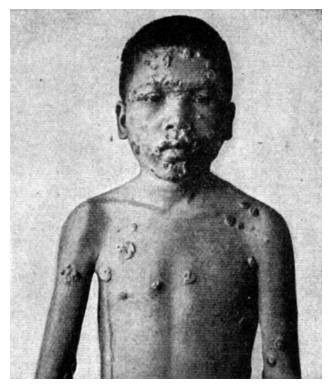


================ MODEL OUTPUT =================
Model Diagnostic Answer:
Diagnosis: Dracunculus medinensis infection
Reasoning: The patient's presentation with a chronic, weeping, cauliflower-like papule on her arm, along with systemic symptoms such as fever, headache, and joint aches, suggests a chronic, localized infection. The location in the Kwango Province of the Democratic Republic of Congo, an endemic area for dracunculus medinensis, raises suspicion for dracunculiasis. The history of an itchy, weeping skin lesion that has progressed to a fungating sore is consistent with the natural progression of dracunculus medinensis infection. The presence of small cuts and abrasions on her extremities, along with lymphadenopathy, further supports the diagnosis. The lack of vaccination history for tropical diseases also makes dracunculiasis a more likely consideration. Therefore, dracunculus medinensis infection is the most probable diagnosis.

Model Reasoning:


========== COMPARING =====

In [4]:
# ==============================================================================
# TEST CASE
# ==============================================================================
test_case = {
    "question": (
        "A 7-year-old girl, hailing from a rural village in the Kwango Province of the "
        "Democratic Republic of Congo, presents with a history of an itchy, weeping skin "
        "lesion on her left forearm that appeared approximately one month ago. She reports "
        "intermittent fevers, headaches, and joint aches for the past two weeks. Her mother "
        "notes that the lesion started as a small bump and has since enlarged into a raised, "
        "cauliflower-like sore that bleeds easily when touched. The girl spends most of her "
        "time playing outdoors and has several small cuts and abrasions on her extremities "
        "from previous falls. She has not received any vaccinations for tropical diseases. "
        "On physical examination, her temperature is 38.2°C. A single, large, fungating, "
        "raspberry-like papule, approximately 2 cm in diameter, is present on her left "
        "forearm, exuding a yellowish, sero-purulent fluid. There is mild tenderness and "
        "palpable enlargement of the left epitrochlear and axillary lymph nodes. "
        "What is the diagnosis of this patient?"
    ),
    "answer": "Yaws or Framboesia, Primary Lesion",
    "clinical_rationale": (
        "The patient is a child from a region endemic for Yaws (Sub-Saharan Africa, "
        "specifically rural Democratic Republic of Congo). The primary inoculation lesion, "
        "described as a 'raspberry-like' or fungating papule that bleeds easily and exudes "
        "sero-purulent fluid, is highly characteristic of the primary stage of Yaws. "
        "Prodromal symptoms such as fever, headache, and arthralgia, along with regional "
        "lymphadenopathy, further support the diagnosis. Risk factors include age, outdoor "
        "play, skin abrasions, and lack of vaccination. Competing diagnoses such as impetigo, "
        "syphilis, and cutaneous leishmaniasis are less consistent with the lesion morphology "
        "and epidemiology."
    ),
    "image_path": "/kaggle/input/ngoc-data-extract/extracted-images/i400.jpg"
}

# ==============================================================================
# 6. RUN INFERENCE
# ==============================================================================
image = load_image(test_case["image_path"])

(pred_answer, pred_rationale), raw_output = run_inference(
    test_case["question"],
    image
)

# ==============================================================================
# 7. DISPLAY OUTPUT
# ==============================================================================
print("\n================ QUESTION =================")
print(test_case["question"])

if image is not None:
    print("\n================ IMAGE =================")
    plt.imshow(image)
    plt.axis("off")
    plt.show()

print("\n================ MODEL OUTPUT =================")
print(f"Model Diagnostic Answer:\n{pred_answer}")
print("\nModel Reasoning:")
print(pred_rationale)

print("\n========== COMPARING ==========")
print(f"Source Answer:\n{test_case['answer']}")
print("\nSource Reasoning:")
print(test_case["clinical_rationale"])